<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/SectorWiseCorrelationAnalysis/SectorWiseCorrelationAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
tickers = ['XLK', 'XLF', 'XLV', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'XLRE', 'XLC']
data = yf.download(tickers, start = '2023-01-01', end = '2026-01-01', auto_adjust=False)['Adj Close'].pct_change().dropna()

data.head()

[*********************100%***********************]  11 of 11 completed


Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,
2023-01-04,0.017397,0.018721,-0.000118,0.016025,0.008840,0.002596,0.003905,0.022929,0.009078,0.002658,0.014487
2023-01-05,-0.015833,0.001414,0.018248,-0.007456,-0.010776,-0.019420,-0.010059,-0.029272,-0.021648,-0.010234,-0.009290
2023-01-06,0.034363,0.016334,0.018969,0.022248,0.027388,0.029295,0.026690,0.029068,0.020115,0.009224,0.023481
2023-01-09,0.006346,0.001587,-0.003540,-0.003675,-0.004459,0.011625,-0.009765,-0.000528,0.006761,-0.016732,0.006057
2023-01-10,0.010015,0.015055,0.007106,0.005674,0.005475,0.006182,-0.001333,0.002905,0.000280,0.008396,0.012569


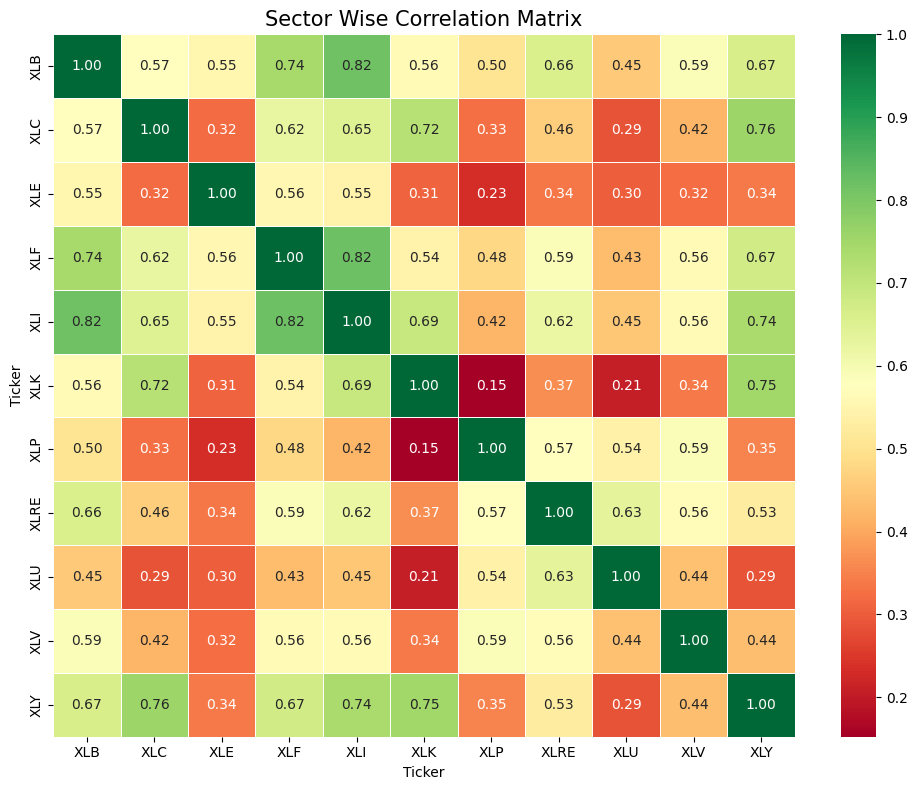

In [ ]:
corr_matrix = data.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot = True,
            cmap='RdYlGn',
            # center=0.5,
            fmt=".2f",
            linewidths=0.5)

plt.title('Sector Wise Correlation Matrix', fontsize=15)
plt.tight_layout()
plt.show()

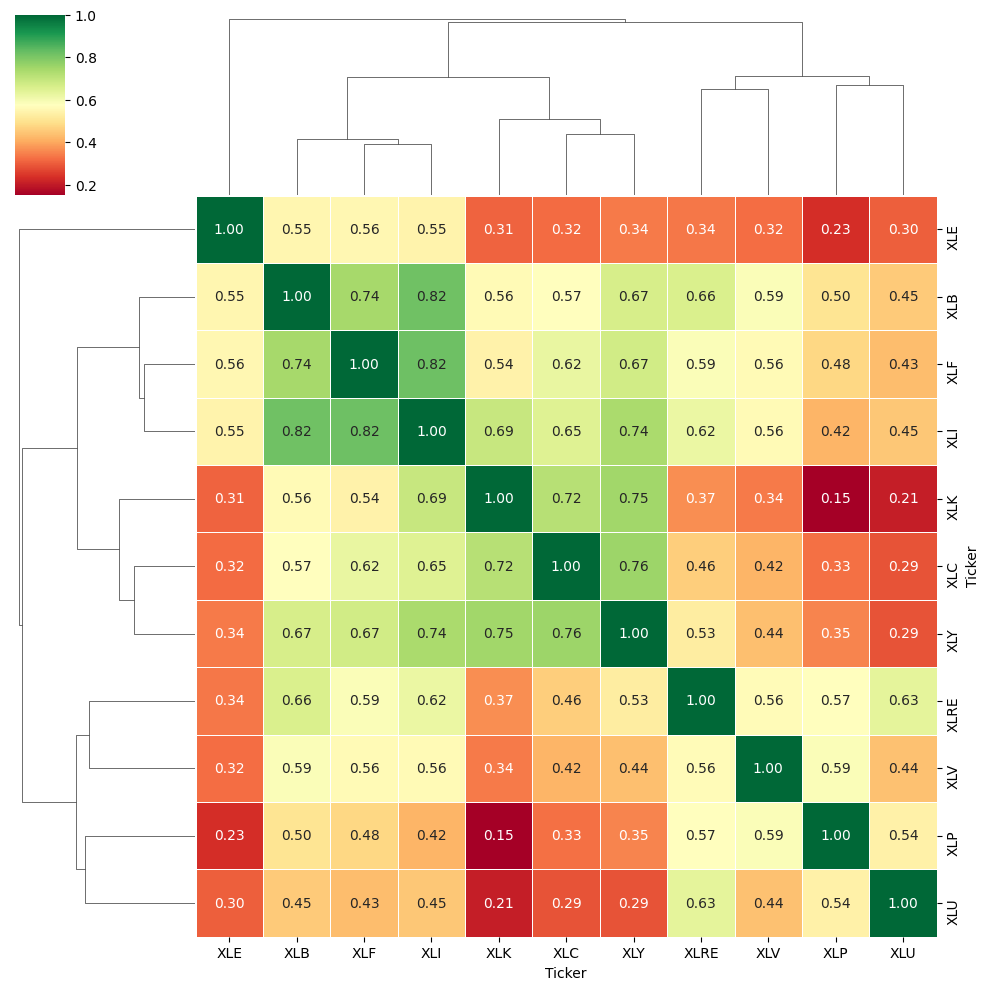

In [ ]:
sns.clustermap(corr_matrix,
               annot = True,
               cmap='RdYlGn',
               fmt=".2f",
               linewidths=0.5)

Very Low Correlation between XLE(ENERGY) and XLP(Consumer Staples). Analyzing these two in depth

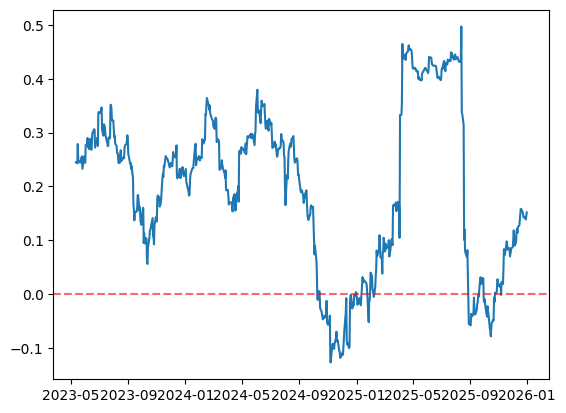

In [ ]:
window = 90

rolling_corr = data['XLE'].rolling(window).corr(data['XLP'])
plt.plot(rolling_corr.index, rolling_corr.values)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.6, label='Correlation = 0')
plt.show()